In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [3]:
data_path = '/Users/franziskakoch/Documents/Uni/UHH/second_semester/LEX/clouds-aerosols-radiation/Data/'
processed_data_path = data_path + 'CloudCamProcessed/'

In [ ]:
brightness = pd.read_csv(processed_data_path + 'CAM1/WMD_CAM1_JPG_20260807/brightness.csv', parse_dates=['timestamp_utc'])
cloud_fraction = pd.read_csv(processed_data_path + 'CAM1/WMD_CAM1_JPG_20260807/cloud_fraction_timeseries.csv', parse_dates=['timestamp_utc'])

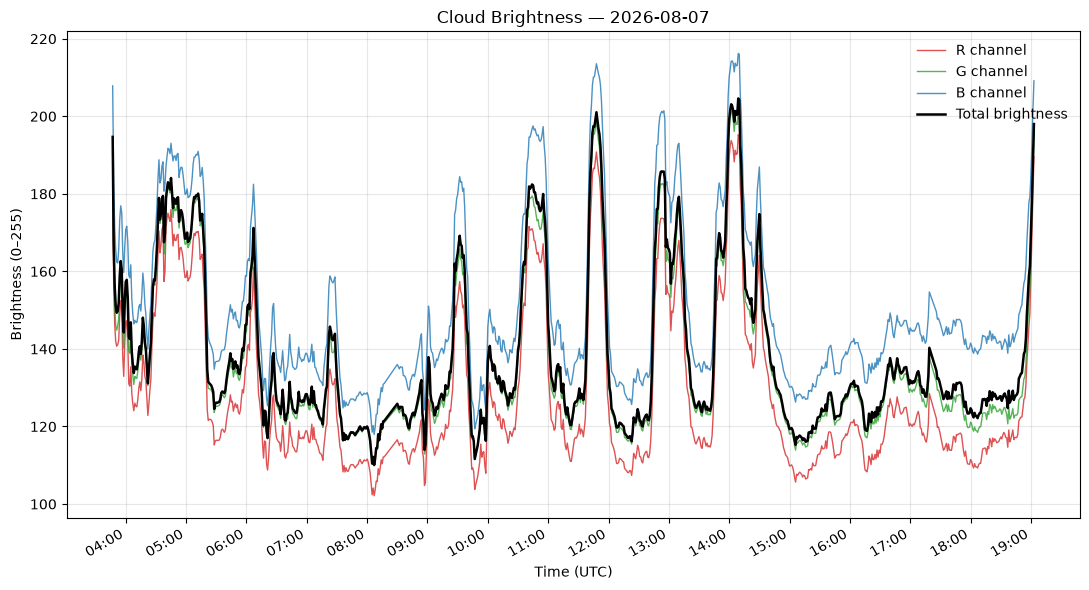

In [9]:
fig, ax1 = plt.subplots(figsize=(11, 6))

ax1.plot(brightness['timestamp_utc'], brightness['mean_r'], color='#d62728', linewidth=1, alpha=0.8, label='R channel')
ax1.plot(brightness['timestamp_utc'], brightness['mean_g'], color='#2ca02c', linewidth=1, alpha=0.8, label='G channel')
ax1.plot(brightness['timestamp_utc'], brightness['mean_b'], color='#1f77b4', linewidth=1, alpha=0.8, label='B channel')
ax1.plot(brightness['timestamp_utc'], brightness['total_mean_brightness'], color='black', linewidth=1.8, label='Total brightness')

ax1.set_xlabel('Time (UTC)')
ax1.set_ylabel('Brightness (0–255)')
ax1.set_title('Cloud Brightness — 2026-08-07')
ax1.legend(loc='upper right', frameon=False)
ax1.grid(alpha=0.3)

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=1))
fig.autofmt_xdate()

fig.tight_layout()
# fig.savefig('brightness_plot.png', dpi=150)

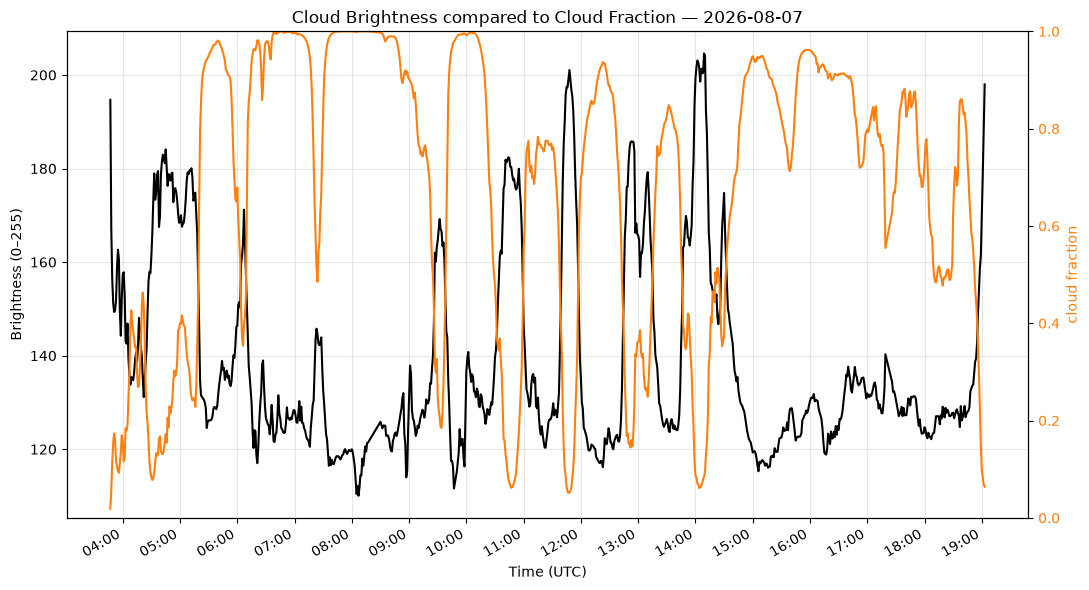

In [10]:
fig, ax1 = plt.subplots(figsize=(11, 6))

ax1.plot(brightness['timestamp_utc'], brightness['total_mean_brightness'], color='black', linewidth=1.5, label='Total brightness')

ax1.set_xlabel('Time (UTC)')
ax1.set_ylabel('Brightness (0–255)')
ax1.set_title('Cloud Brightness compared to Cloud Fraction — 2026-08-07')
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('cloud fraction', color=color)
ax2.plot(cloud_fraction['timestamp_utc'], cloud_fraction['cloud_fraction_total'], color=color, linewidth=1.5, label='Cloud fraction')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 1)

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=1))
fig.autofmt_xdate()

fig.tight_layout()
# fig.savefig('brightness_plot.png', dpi=150)

In [4]:
sunphotometer_data = pd.read_excel(data_path + 'updated2_cloudmeasurements_withclouds.xlsx')
print(sunphotometer_data.DATE)

0     2026-08-12
1     2026-08-12
2     2026-08-12
3     2026-08-12
4     2026-08-12
         ...    
415   2026-08-17
416   2026-08-17
417   2026-08-17
418   2026-08-17
419   2026-08-17
Name: DATE, Length: 420, dtype: datetime64[us]


In [5]:
sunphotometer_data["timestamp"] = (
    sunphotometer_data["DATE"] +  pd.to_timedelta(sunphotometer_data["TIME"].astype(str))
).dt.tz_localize("UTC")

In [6]:
sunphotometer_data["timestamp"] = sunphotometer_data["timestamp"].dt.round("min")
print(sunphotometer_data["timestamp"])

0     2026-08-12 08:28:00+00:00
1     2026-08-12 08:28:00+00:00
2     2026-08-12 08:28:00+00:00
3     2026-08-12 08:36:00+00:00
4     2026-08-12 08:36:00+00:00
                 ...           
415   2026-08-17 08:38:00+00:00
416   2026-08-17 08:38:00+00:00
417   2026-08-17 08:43:00+00:00
418   2026-08-17 08:43:00+00:00
419   2026-08-17 08:43:00+00:00
Name: timestamp, Length: 420, dtype: datetime64[us, UTC]


In [7]:
brightness1 = pd.read_csv(processed_data_path + "CAM1/WMD_CAM1_JPG_20260812/brightness.csv")
brightness2 = pd.read_csv(processed_data_path + "CAM1/WMD_CAM1_JPG_20260813/brightness.csv")
brightness3 = pd.read_csv(processed_data_path + "CAM1/WMD_CAM1_JPG_20260814/brightness.csv")
brightness4 = pd.read_csv(processed_data_path + "CAM1/WMD_CAM1_JPG_20260815/brightness.csv")
brightness5 = pd.read_csv(processed_data_path + "CAM1/WMD_CAM1_JPG_20260817/brightness.csv")

In [12]:
combined_brightness = pd.concat([brightness1, brightness2, brightness3, brightness4, brightness5], ignore_index=True)
combined_brightness["timestamp_utc"] = pd.to_datetime(combined_brightness.timestamp_utc)
print(combined_brightness.timestamp_utc)

0      2026-08-12 03:56:00+00:00
1      2026-08-12 03:57:00+00:00
2      2026-08-12 03:58:00+00:00
3      2026-08-12 03:59:00+00:00
4      2026-08-12 04:00:00+00:00
                  ...           
4364   2026-08-17 18:38:00+00:00
4365   2026-08-17 18:39:00+00:00
4366   2026-08-17 18:40:00+00:00
4367   2026-08-17 18:41:00+00:00
4368   2026-08-17 18:42:00+00:00
Name: timestamp_utc, Length: 4369, dtype: datetime64[us, UTC]


In [13]:
selected = combined_brightness.merge(
    sunphotometer_data.reset_index()[["index", "timestamp"]],
    left_on="timestamp_utc", right_on="timestamp", how="inner"
)
selected = selected.sort_values("index").rename(columns={"index": "sunphotometer_index"})

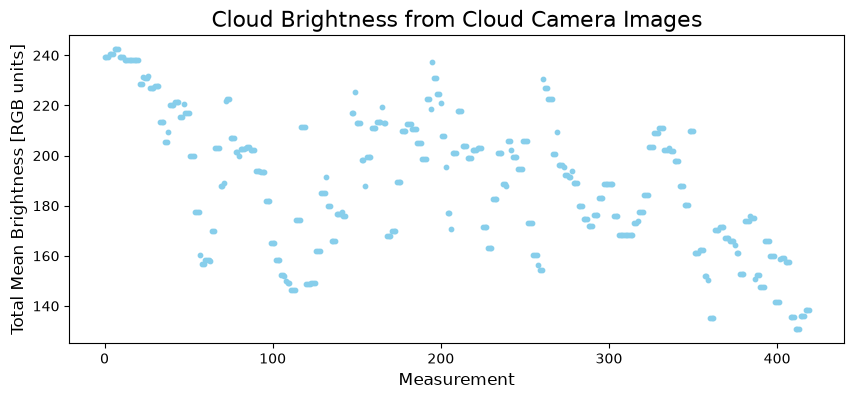

In [17]:
x = selected["sunphotometer_index"]

plt.figure(figsize=(10, 4))

plt.scatter(x, selected["total_mean_brightness"], color="skyblue", s=10)

plt.xlabel("Measurement", fontsize=12)
plt.ylabel("Total Mean Brightness [RGB units]", fontsize=12)
plt.title("Cloud Brightness from Cloud Camera Images", fontsize=16)
plt.show()